import sys
!{sys.executable} -m pip install seaborn cirq scikit-learn

In [4]:
!conda info --envs

/home/cdac/anaconda3/lib/python3.11/site-packages/conda/base/context.py:211: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.9. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/use-condarc.html

  deprecated.topic(

# conda environments:
#
base                   /home/cdac/anaconda3
AI                     /home/cdac/anaconda3/envs/AI
CirqQsim               /home/cdac/anaconda3/envs/CirqQsim
IONQ-CLOUD             /home/cdac/anaconda3/envs/IONQ-CLOUD
MPI-PY                 /home/cdac/anaconda3/envs/MPI-PY
MQT                    /home/cdac/anaconda3/envs/MQT
QiskitAakash           /home/cdac/anaconda3/envs/QiskitAakash
Qiskit_1.2             /home/cdac/anaconda3/envs/Qiskit_1.2
Qsim_Superm

In [1]:
import sys,os

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, Aer, transpile,execute
backend = Aer.get_backend("qasm_simulator")

# Get the absolute path of the project's root directory
cd = os.path.abspath(os.path.join(os.path.dirname("qasm-supermarq"), '..'))

# Add the utils and models directories to sys.path
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq/benchmarks'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks'))

from plotting import *
from converters import *
from benchmarks import GHZ, HamiltonianSimulation, MerminBell, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy
import time
from numpy import mean
import resource

/tmp/ipykernel_69686/267084097.py:4: DeprecationWarning: The 'qiskit.Aer' entry point is deprecated and will be removed in Qiskit 1.0. You should use 'qiskit_aer.Aer' directly instead.
  backend = Aer.get_backend("qasm_simulator")


In [2]:
def run(benchmark_class,min_qubits,max_qubits,num_ckts,name):
    data = {}
    creation_times = []
    execution_times = []
    quantum_times = []
    features_set = []
    scores = []
    memory = []
    for qubits in range(min_qubits,max_qubits+1):
        print("****************************************************")
        print( f"Executing {num_ckts} circuits with {qubits} qubits")
        circuit_name = f"{name}-{qubits}"
        
        for ckt in range(num_ckts):
            # start execution for each circuit
            benchmark_obj = benchmark_class(qubits)
            # Calculate Creation time 
            t_c = time.time()
            qc= benchmark_obj.qiskit_circuit().reverse_bits()
            creation_time = time.time()-t_c  #in sec
            creation_times.append(creation_time)
            #print(qc)
    
            # Calculate Execution time 
            t_e = time.time()
            job = execute(qc,backend,shots = 1024)
            result = job.result()
            execution_time = time.time() - t_e #in sec
        
            # Calculate quantum processing time 
            quantum_time = (result.time_taken) #in sec
            execution_times.append(execution_time)
            quantum_times.append(quantum_time)
            
            #Calculate score of the fidelity
            counts = result.get_counts()
            print("counts : ",counts)
            score = benchmark_obj.score(counts)
            #print("Score : ",score)
            scores.append(score)

            features = [
            compute_communication_with_qiskit(qc),
            compute_depth_with_qiskit(qc),
            compute_entanglement_with_qiskit(qc),
            compute_liveness_with_qiskit(qc),
            compute_measurement_with_qiskit(qc),
            compute_parallelism_with_qiskit(qc),
            ]
            features_set.append(features)
            #print("Features :",features)

            
        #average values calculation
        print(f"Average result of {num_ckts} circuits of {qubits} qubits are:") 
        creation_time, execution_time, quantum_time = mean(creation_times),mean(execution_times), mean(quantum_times)
        print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")
        Features = list(mean(features_set, axis=0))
        print(f"Features of {qubits}-qubit circuits: {Features}")
        score = mean(scores)
        print(f"SCORE = {score}")
        print("****************************************************")

        data[circuit_name]={'creation_time':creation_time,'execution_time': execution_time,'quantum_time': quantum_time,'score':score,'Features':Features}
    print("data = ",data)
    return data    

In [3]:
def get_fidelity_plots(data):
    #score plots
    circuits = list(data.keys())
    scores = []
    features_set=[]
    for i in list(data.values()):
        scores.append(i['score'])
        features_set.append(i['Features'])
    plot_results(scores,circuits)

# GHZ:

****************************************************
Executing 2 circuits with 2 qubits


/tmp/ipykernel_69686/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'11': 519, '00': 505}
counts :  {'11': 497, '00': 527}
Average result of 2 circuits of 2 qubits are:
Creation, execution and Quantum Times = 0.0001976490020751953,1.3874835968017578 & 0.0016965866088867188 seconds
Features of 2-qubit circuits: [1.0, 1.0, 0.5, 0.8333333333333334, 0.0, 0.0]
SCORE = 0.9998693224952322
****************************************************
****************************************************
Executing 2 circuits with 3 qubits
counts :  {'111': 483, '000': 541}
counts :  {'111': 475, '000': 549}
Average result of 2 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.00019532442092895508,0.6973344683647156 & 0.0015657544136047363 seconds
Features of 3-qubit circuits: [0.8333333333333333, 1.0, 0.5833333333333333, 0.75, 0.0, 0.0]
SCORE = 0.9994071678610127
****************************************************
****************************************************
Executing 2 circuits with 4 qubits
counts :  {'0000': 509, '1111': 515}
coun

/tmp/ipykernel_69686/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'00000000000': 492, '11111111111': 532}
Average result of 2 circuits of 11 qubits are:
Creation, execution and Quantum Times = 0.0002668619155883789,0.14640966653823853 & 0.0024957895278930665 seconds
Features of 11-qubit circuits: [0.403975468975469, 1.0, 0.7980122655122655, 0.4392965367965368, 0.0, 0.0]
SCORE = 0.9997147766157306
****************************************************
data =  {'GHZ-2': {'creation_time': 0.0001976490020751953, 'execution_time': 1.3874835968017578, 'quantum_time': 0.0016965866088867188, 'score': 0.9998693224952322, 'Features': [1.0, 1.0, 0.5, 0.8333333333333334, 0.0, 0.0]}, 'GHZ-3': {'creation_time': 0.00019532442092895508, 'execution_time': 0.6973344683647156, 'quantum_time': 0.0015657544136047363, 'score': 0.9994071678610127, 'Features': [0.8333333333333333, 1.0, 0.5833333333333333, 0.75, 0.0, 0.0]}, 'GHZ-4': {'creation_time': 0.00019359588623046875, 'execution_time': 0.4672536849975586, 'quantum_time': 0.001559933026631673, 'score': 0.999602

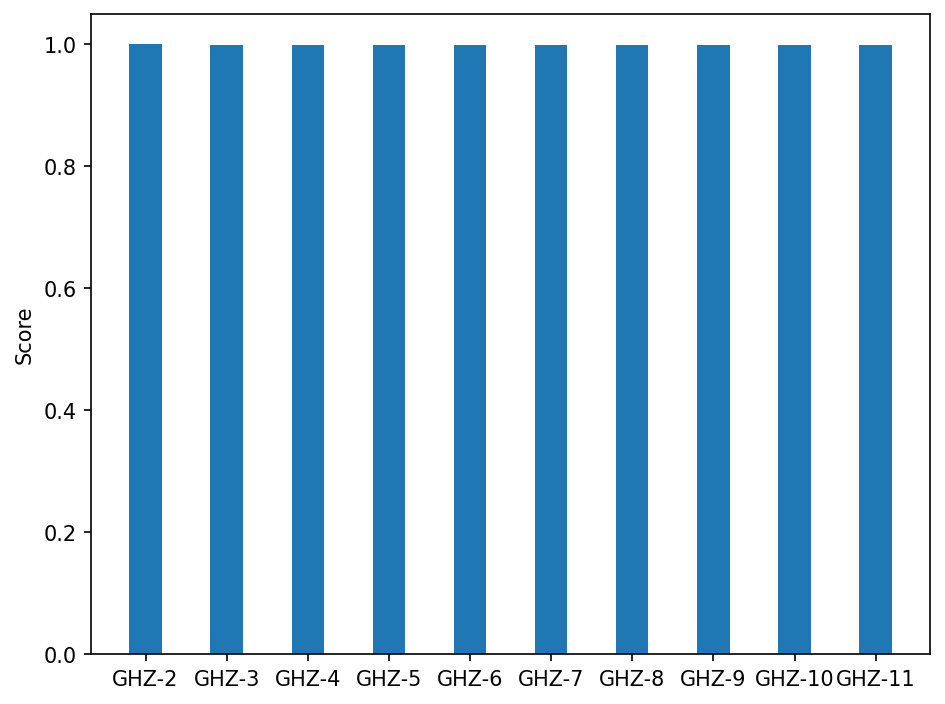

In [4]:
data = run(GHZ,min_qubits=2,max_qubits=11,num_ckts=2,name="GHZ")
get_fidelity_plots(data)

# Hamiltonian:

****************************************************
Executing 1 circuits with 2 qubits
counts :  {'01': 122, '00': 20, '10': 120, '11': 762}
Average result of 1 circuits of 2 qubits are:
Creation, execution and Quantum Times = 0.0004558563232421875,0.011996269226074219 & 0.004648447036743164 seconds
Features of 2-qubit circuits: [1.0, 1.0, 0.2222222222222222, 0.9285714285714286, 0.0, 0.5]
SCORE = 0.9912487030932738
****************************************************
****************************************************
Executing 1 circuits with 3 qubits
counts :  {'000': 2, '010': 13, '001': 18, '100': 19, '110': 115, '101': 100, '011': 109, '111': 648}
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.0004899501800537109,0.013030052185058594 & 0.004825949668884277 seconds
Features of 3-qubit circuits: [0.8333333333333333, 1.0, 0.24444444444444444, 0.8309523809523809, 0.0, 0.4166666666666667]
SCORE = 0.9923880260099405
****************************

/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)
/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)
/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0

counts :  {'010010': 1, '101000': 1, '110100': 2, '000111': 1, '100110': 4, '001101': 1, '001110': 2, '010001': 1, '111110': 75, '010101': 3, '110010': 2, '111001': 15, '101110': 6, '110101': 13, '011110': 12, '111010': 10, '101101': 17, '101111': 59, '010111': 15, '111011': 80, '110011': 8, '110001': 4, '001011': 3, '101001': 1, '011101': 15, '110111': 77, '111111': 385, '111101': 64, '110110': 8, '011100': 4, '111100': 12, '101011': 9, '100101': 2, '100011': 3, '101100': 3, '001111': 9, '101010': 3, '011011': 11, '011111': 68, '100111': 12, '011010': 3}
Average result of 1 circuits of 6 qubits are:
Creation, execution and Quantum Times = 0.0004888534545898438,0.0135650634765625 & 0.005968904495239258 seconds
Features of 6-qubit circuits: [0.58, 1.0, 0.27478595478595474, 0.6375766338924234, 0.0, 0.29000000000000004]
SCORE = 0.9955934906186548
****************************************************
data =  {'Hamiltonian Simulation-2': {'creation_time': 0.0004558563232421875, 'execution_ti

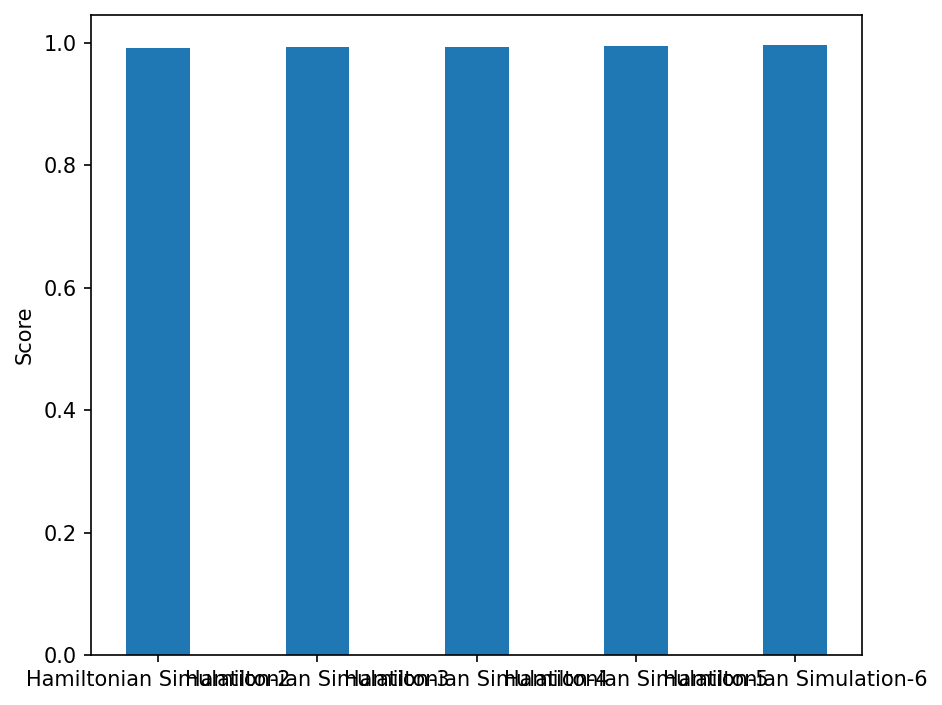

In [5]:
data = run(HamiltonianSimulation,min_qubits=2,max_qubits=6,num_ckts=1,name="Hamiltonian Simulation")
get_fidelity_plots(data)

# Mermin Bell:

****************************************************
Executing 1 circuits with 2 qubits
counts :  {'01': 1024}
Average result of 1 circuits of 2 qubits are:
Creation, execution and Quantum Times = 0.0015606880187988281,0.011601924896240234 & 0.004941701889038086 seconds
Features of 2-qubit circuits: [1.0, 1.0, 0.3333333333333333, 0.875, 0.0, 0.2857142857142858]
SCORE = 1.0
****************************************************
****************************************************
Executing 1 circuits with 3 qubits
counts :  {'001': 1024}
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.0016661882400512695,0.015397071838378906 & 0.006512165069580078 seconds
Features of 3-qubit circuits: [1.0, 1.0, 0.38541666666666663, 0.7708333333333333, 0.0, 0.22619047619047622]
SCORE = 1.0
****************************************************
****************************************************
Executing 1 circuits with 4 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'0001': 1024}
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.0017655690511067708,0.014884630839029947 & 0.006008466084798177 seconds
Features of 4-qubit circuits: [1.0, 0.9743589743589745, 0.43027777777777776, 0.7083333333333334, 0.0, 0.20308123249299723]
SCORE = 1.0
****************************************************
****************************************************
Executing 1 circuits with 5 qubits
counts :  {'00001': 1024}
Average result of 1 circuits of 5 qubits are:
Creation, execution and Quantum Times = 0.0025156140327453613,0.013683736324310303 & 0.005764365196228027 seconds
Features of 5-qubit circuits: [1.0, 0.9544534412955467, 0.4624142156862745, 0.6573369565217391, 0.0, 0.186401833460657]
SCORE = 1.0
****************************************************
****************************************************
Executing 1 circuits with 6 qubits
counts :  {'000001': 1024}
Average result of 1 circuits of 6 qubits are:
Creatio

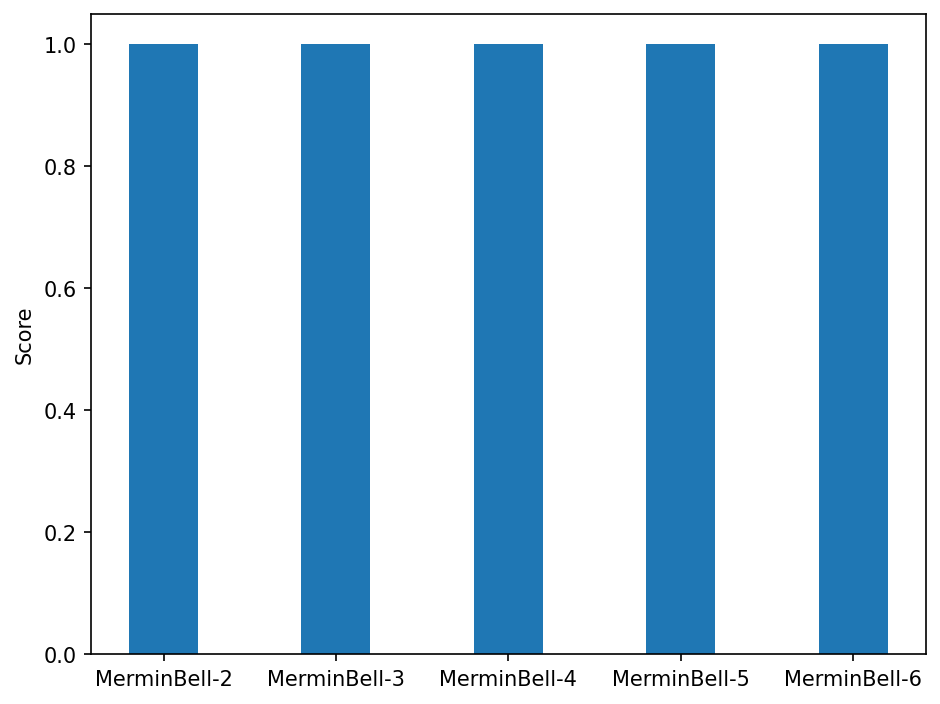

In [6]:
data = run(MerminBell,min_qubits=2,max_qubits=6,num_ckts=1,name="MerminBell")
get_fidelity_plots(data)

# QAOAFermonicsSwapProxy:

****************************************************
Executing 1 circuits with 2 qubits
counts :  {'01': 509, '10': 515}
Average result of 1 circuits of 2 qubits are:
Creation, execution and Quantum Times = 0.0007233619689941406,0.00903630256652832 & 0.003999948501586914 seconds
Features of 2-qubit circuits: [1.0, 1.0, 0.375, 0.9285714285714286, 0.0, 0.33333333333333326]
SCORE = 0.9999999862967068
****************************************************
****************************************************
Executing 1 circuits with 3 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)
/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'000': 185, '100': 149, '111': 176, '011': 174, '110': 167, '001': 173}
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.0008711814880371094,0.01136636734008789 & 0.004071831703186035 seconds
Features of 3-qubit circuits: [0.8333333333333333, 1.0, 0.4375, 0.7976190476190477, 0.0, 0.23809523809523808]
SCORE = 0.9999999809491945
****************************************************
****************************************************
Executing 1 circuits with 4 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'0000': 199, '0010': 96, '0100': 112, '0110': 4, '1101': 87, '1010': 53, '1100': 48, '1111': 210, '0001': 1, '1011': 113, '0111': 1, '0011': 43, '1001': 5, '0101': 52}
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.001047054926554362,0.010957002639770508 & 0.004223187764485677 seconds
Features of 4-qubit circuits: [0.7222222222222222, 0.8888888888888888, 0.4791666666666667, 0.7685881370091897, 0.0, 0.24514991181657844]
SCORE = 0.996675327278102
****************************************************
****************************************************
Executing 1 circuits with 5 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'01101': 3, '11101': 2, '00111': 33, '10000': 2, '11011': 26, '00000': 1, '01011': 5, '11111': 3, '11000': 37, '00100': 30, '10110': 33, '01111': 11, '01100': 122, '10101': 2, '11100': 1, '10010': 1, '00001': 11, '10111': 139, '11010': 5, '10001': 45, '01001': 46, '00101': 14, '10011': 131, '01110': 44, '11001': 68, '10100': 3, '11110': 14, '01000': 134, '00110': 58}
Average result of 1 circuits of 5 qubits are:
Creation, execution and Quantum Times = 0.001248478889465332,0.010895848274230957 & 0.004355728626251221 seconds
Features of 5-qubit circuits: [0.6416666666666666, 0.7916666666666666, 0.509375, 0.7612237114525444, 0.0, 0.2634078884078884]
SCORE = 0.9968818241493385
****************************************************
****************************************************
Executing 1 circuits with 6 qubits
counts :  {'000010': 1, '001011': 3, '110101': 2, '111000': 2, '101110': 1, '001010': 3, '100101': 4, '001101': 16, '011010': 2, '100100': 6, '111101': 1, '001000': 2

/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


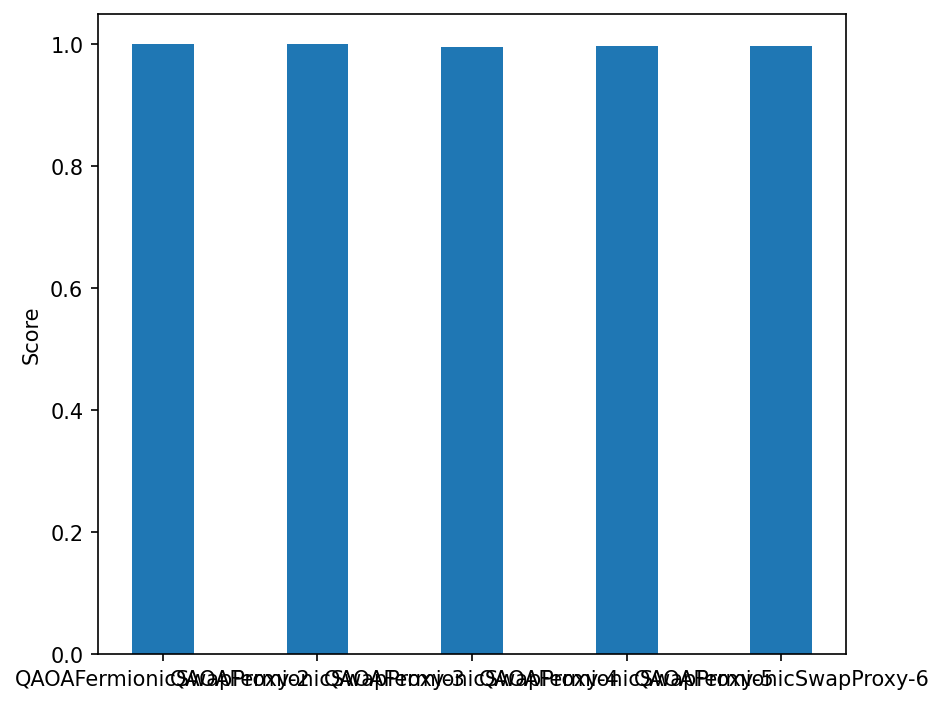

In [7]:
data = run(QAOAFermionicSwapProxy,min_qubits=2,max_qubits=6,num_ckts=1,name="QAOAFermionicSwapProxy")
get_fidelity_plots(data)

# QAOAVanillaProxy:

****************************************************
Executing 1 circuits with 2 qubits
counts :  {'01': 529, '10': 495}
Average result of 1 circuits of 2 qubits are:
Creation, execution and Quantum Times = 0.0006999969482421875,0.011821746826171875 & 0.003976345062255859 seconds
Features of 2-qubit circuits: [1.0, 1.0, 0.2857142857142857, 0.9166666666666666, 0.0, 0.3999999999999999]
SCORE = 0.9999999913537694
****************************************************
****************************************************
Executing 1 circuits with 3 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)
/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'110': 167, '100': 190, '111': 161, '011': 169, '000': 161, '001': 176}
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.0008149147033691406,0.010645627975463867 & 0.0040435791015625 seconds
Features of 3-qubit circuits: [1.0, 1.0, 0.34285714285714286, 0.7916666666666666, 0.0, 0.29090909090909084]
SCORE = 0.9999999862306187
****************************************************
****************************************************
Executing 1 circuits with 4 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'1011': 1, '1101': 75, '0011': 203, '0111': 98, '1100': 206, '0110': 11, '1000': 109, '1001': 8, '0101': 50, '0010': 100, '0000': 55, '1010': 53, '1111': 54, '0001': 1}
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.0009575684865315756,0.010316928227742514 & 0.004123767217000325 seconds
Features of 4-qubit circuits: [1.0, 0.9444444444444445, 0.3824175824175824, 0.7222222222222222, 0.0, 0.2527629233511586]
SCORE = 0.996840726927299
****************************************************
****************************************************
Executing 1 circuits with 5 qubits


/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


counts :  {'00010': 1, '01101': 28, '01110': 73, '10001': 49, '00101': 55, '11010': 57, '01001': 1, '10011': 33, '10101': 227, '10010': 21, '11100': 3, '10000': 28, '11011': 21, '11000': 20, '01010': 220, '11110': 8, '00111': 27, '00011': 2, '01111': 23, '00100': 21, '00001': 19, '00110': 24, '01100': 20, '01000': 2, '10100': 2, '01011': 1, '10110': 3, '11101': 3, '11001': 30, '00000': 2}
Average result of 1 circuits of 5 qubits are:
Creation, execution and Quantum Times = 0.001116335391998291,0.010283112525939941 & 0.004225015640258789 seconds
Features of 5-qubit circuits: [1.0, 0.9083333333333334, 0.4118131868131868, 0.662037037037037, 0.0, 0.22322603866721508]
SCORE = 0.9949410865980378
****************************************************
****************************************************
Executing 1 circuits with 6 qubits
counts :  {'110010': 1, '011100': 2, '101111': 1, '100010': 1, '011110': 3, '000111': 2, '100001': 3, '101000': 2, '100011': 3, '000000': 20, '110011': 2, '0100

/tmp/ipykernel_31096/1990957911.py:26: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc,backend,shots = 1024)


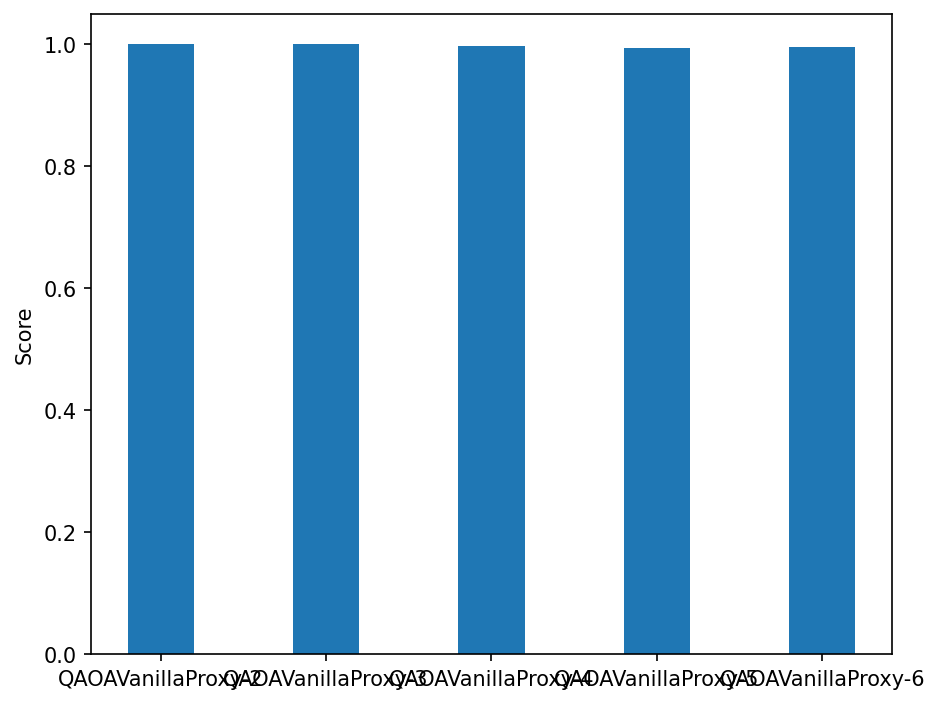

In [8]:
data = run(QAOAVanillaProxy,min_qubits=2,max_qubits=6,num_ckts=1,name="QAOAVanillaProxy")
get_fidelity_plots(data)

import simulation,time

def VQEP(qubits,l):
    
    name = "VQE_Proxy"
    final_counts = []
    ckt_list = []
    execution_times = []
    quantum_times = []
    
    # Calculate Creation time 
    t_c = time.time()
    #vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
    vqe = VQEProxy(qubits, l)
    shots = 1000
    ckts =  vqe.circuit()
    creation_time = time.time()-t_c
    
    for i in ckts:
        ckt_list.append(cirq_to_qiskit(i))
    
    #print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")
    
    # for i in ckts:
    #     print(i)
    
    for i in ckt_list:
        t_e = time.time()
        job = execute(i, backend, shots=shots)
        result = job.result()
        execution_time = time.time() - t_e #in sec
    
        # Calculate quantum processing time 
        quantum_time = (result.time_taken) #in sec
    
        #print(f" For circuit i, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
        
        counts = result.results[0].data.partial_probability
        for key in counts.keys():
            counts[key] = int(counts[key] * shots)
    
        print(f" For circuit i={i.name}, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
    
        final_counts.append(counts)
        execution_times.append(execution_time)
        quantum_times.append(quantum_time)
    print("Final Counts:",final_counts)
    qubits = vqe.num_qubits
    print(f"for {len(ckt_list)} circuits of {qubits} qubits Creation time = {creation_time} sec, Execution time = {sum(execution_times)} sec and quantum time = {sum(quantum_times)} sec")
    
    score_vqe = vqe.score(final_counts)
    print(score_vqe)
    
    
    benchmark_name = f"{name}-{qubits}"
    plot_results([score_vqe],[benchmark_name])
    
    print("########################################################")

    # #Features = dict()
        
    # for i in ckt_list:
    #     features = [
    #     compute_communication_with_qiskit(i),
    #     compute_depth_with_qiskit(i),
    #     compute_entanglement_with_qiskit(i),
    #     compute_liveness_with_qiskit(i),
    #     compute_measurement_with_qiskit(i),
    #     compute_parallelism_with_qiskit(i),
    #     ]
    #     print(f"Features for ckt {i.name}: {features}")
    #     Features[str(name)+{i.name}] = features
    #     plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
    #                        spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    
    # vqe_label = str(name)+"_"+str(qubits)
    # vqe_features = Features
    # vqe_score = score_vqe

if __name__=="__main__":
    for i in range(2,7):
        VQEP(i,1)